Import libraries

In [1]:
%matplotlib inline
from qiskit_aer import AerSimulator
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

Change the token to the one in your account. You should see "API Token" next to "IBM Quantum Platform" in your dashboard after you login.

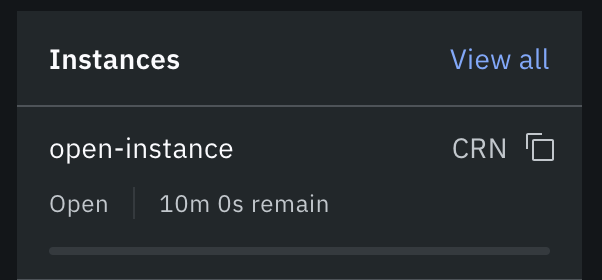

In [ ]:
token = "your_API_token_here"
CRN="copy_The service instance to use.here CRN"

Use AER for simulation on local and see your results, you can also Connect to QiskitRuntimService and build circuit here but just using the WEB interface is sufficient and easy for this HW.

qiskit_runtime_service._discover_account:WARNING:2025-11-18 17:46:06,092: Loading account with the given token. A saved account will not be used.


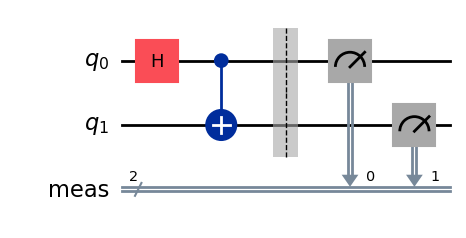

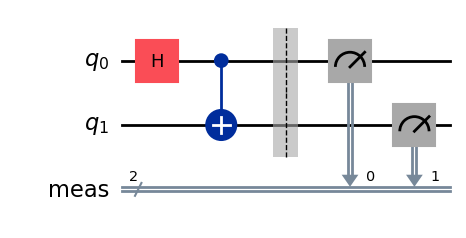

In [ ]:
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance=CRN)
 
# Change this to your Deutsch-Jozsa circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
qc.draw("mpl")

Run circuit in Aer simulator and get result.

In [4]:
aer_sim = AerSimulator()
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
isa_qc = pm.run(qc)
sampler = Sampler(mode=aer_sim)
result = sampler.run([isa_qc]).result()[0]

Get counts of different measurement results. Note to get an estimation of the state, we execute and measure the circuit many times (1024 times is the default) and count the number of ocurrances of different outcomes. For example, here we execute and measure this Bell circuit 1024 times (simulated obvisouly) and we see the occurance of '00' and '11' each being close to 512.

In [5]:
counts = result.data.meas.get_counts()
counts

{'11': 519, '00': 505}

Do a simple plot

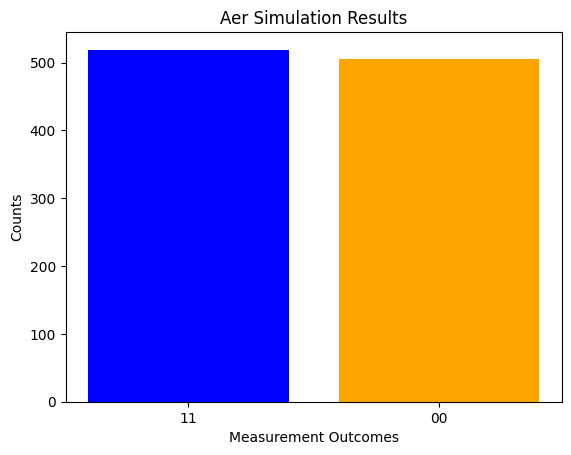

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots() 
ax.bar(counts.keys(), counts.values(), color=['blue', 'orange'])
ax.set_xlabel('Measurement Outcomes') 
ax.set_ylabel('Counts') 
ax.set_title('Aer Simulation Results')
plt.show()

## minimal QASM code scripting example
This section runs OpenQASM-defined  using Aer + Sampler, then shows a minimal QASM Bell example with explicit classical registers.

Minimal QASM Bell counts: {'00': 535, '11': 489}


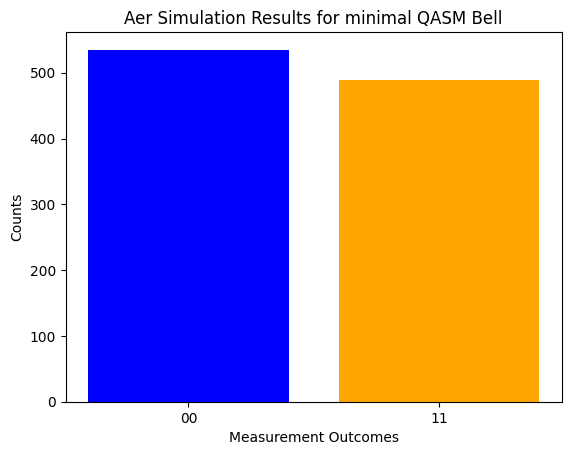

Circuit for minimal QASM Bell
        ┌───┐     ┌─┐    ░ ┌─┐   
   q_0: ┤ H ├──■──┤M├────░─┤M├───
        └───┘┌─┴─┐└╥┘┌─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─╫─┤M├─░──╫─┤M├
             └───┘ ║ └╥┘ ░  ║ └╥┘
   c: 2/═══════════╩══╩═════╬══╬═
                   0  1     ║  ║ 
meas: 2/════════════════════╩══╩═
                            0  1 


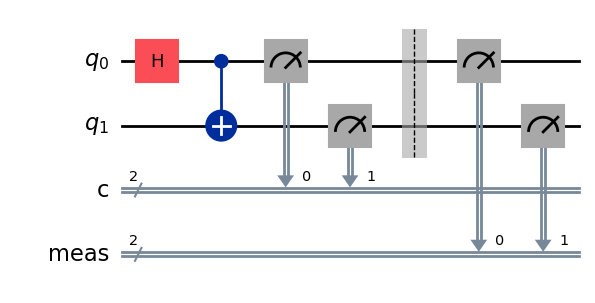

********************************


In [7]:


# Minimal QASM Bell example with explicit classical registers
import matplotlib.pyplot as plt
qasm_code_min = """
OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0], q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];
"""

aer_sim = AerSimulator()


circuit_min = QuantumCircuit.from_qasm_str(qasm_code_min)
circuit_min.measure_all()
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
isa_qc_min = pm.run(circuit_min)

sampler = Sampler(mode=aer_sim)
result_min = sampler.run([isa_qc_min]).result()[0]
counts_min = result_min.data.meas.get_counts()
print("Minimal QASM Bell counts:", counts_min)

fig, ax = plt.subplots()
keys = list(counts_min.keys())
ax.bar(keys, [counts_min[k] for k in keys], color=['blue', 'orange'])
ax.set_xlabel('Measurement Outcomes')
ax.set_ylabel('Counts')
ax.set_title('Aer Simulation Results for minimal QASM Bell')
plt.show()

print("Circuit for minimal QASM Bell")
print(circuit_min.draw(output='text'))

fig = circuit_min.draw(output='mpl')
plt.show()
print("********************************")